# GRAZING → SRIM MNT Pipeline

Full pipeline from raw GRAZING output to a degrader/gas-catcher design: parses a GRAZING run,
Monte-Carlo samples an event list for a chosen isotope, then runs those events through the
target/degrader/He-gas energy-loss chain to get optimal degrader thicknesses and expected ranges.

| Part | What it does |
|---|---|
| **1. Parsing GRAZING output** | Reads `fort.10`/`fort.95`/`fort.96`, splits into per-isotope cross-section curves, auto-cleans known data glitches |
| **2. Event generation** | Monte-Carlo samples an (angle, ΔE) event list for one isotope |
| **3. SRIM setup** | SRIM/pysrim helper functions (`fastSRIM`, `inelScatter`, unit conversions) |
| **4. Reaction & degrader parameters** | Per-reaction physical parameters, including a kinematics-source toggle |
| **5. Energy out of target** | Attenuates the reaction kinematics through the remaining target thickness — this is where GRAZING events plug in |
| **6. Energy out of degrader** | Degrader foil + He gas energy loss |
| **7. Degrader thickness optimization** | Optimal degrader thickness vs. angle |
| **8. Small-angle degrader calculator** | Single-angle degrader thickness for a beam aimed directly at the degrader |

**Important — Parts 3 onward need SRIM installed locally.** They depend on `pysrim` and a working
copy of `SRIM.exe` (Windows), so they can only be run on a machine with that setup — they are not
executed in this build. Parts 1-2 have no such dependency and are fully self-contained.


## Producing the `fort.10`/`fort.95`/`fort.96` files this notebook reads

GRAZING is run by piping a plain-text answer file into the executable, one line per prompt —
GRAZING then writes `fort.95`/`fort.96` (and echoes the input back out as `fort.10`) into the
working directory:

```bash
cat grazing_input.txt | ./grazing_9 > run_output.log 2>&1
```

Below is a real, working example of that input file — the exact one used to produce the
`data/run100/` sample bundled with this notebook (40Ar beam on a 208Pb target, 6 selected
projectile-like partitions). Save it as a `.txt` file and use it as a template for new runs:

```text
OK
18   40   82  208 
s   
no  
   2  
   0.00000 
   0.00000 
   6.50000 
   4    
   0.0000   0.00  
lab  
    4 
yes  
no   
no
no
    6
   0  -3
   1  -3
   3  -1
   -1 -2 
   -1 -1
   1   1
 0.0,-20 
rad 
no  
no  
```

Line-by-line, in order: `OK` (start), `Z_beam A_beam Z_target A_target`, a fixed accuracy flag
(`s`), a fixed additional-output flag (`no`), inelastic-model option, center-of-mass energy (`0`
= unused), lab energy (`0` = unused), **lab energy per nucleon in MeV/u** (the actual beam
energy — `6.50000` here), a fixed `leg` flag, energy-step/max (`0 0` = single fixed-energy run,
not a scan), reference frame (`lab`), a fixed `leg4` flag, Wilczynski-plot yes/no, two more
additional-output flags, **number of selected partitions**, then that many `deltaN deltaZ` lines
(one per isotope you want tabulated — see Part 1.2 for how these map to actual isotopes), energy
resolution/cutoff, Wilczynski-plot units, and two final `no`s to end the run without chaining
into another one.

To scan a different isotope range (like the 40Ar + 196Pt / 10-partition example used later in this
notebook), only three things change: the `Z_target A_target` on line 2, the number of partitions,
and the `deltaN deltaZ` list itself — everything else stays the same as above.


**Setup:** Parts 1-2 need `numpy`, `pandas`, and `matplotlib`. If you don't have them, run
the cell below once (or `pip install numpy pandas matplotlib` from a terminal). Part 3 onward
additionally needs `scipy` and `pysrim` (see Part 3's setup note).

**Folder layout:** keep this notebook in the same folder as the `data/` folder that ships with
it:

```
<this folder>/
├── GRAZING_SRIM_pipeline.ipynb
└── data/
    └── run100/
        ├── fort.10
        ├── fort.95
        └── fort.96
```


In [ ]:
# Uncomment and run once if numpy/pandas/matplotlib aren't already installed:
# %pip install numpy pandas matplotlib


## 1. Parsing GRAZING output

### 1.1 A tiny C++-`ifstream`-style reader

`fort.10` (the run's input echo) has a fixed, slightly awkward layout: to find the list of
selected isotopes you have to skip tokens until the literal word `lab` shows up, then read the
`(ΔN, ΔZ)` pairs that follow it. The cleanest way to reproduce that scan in Python is to mimic
the two read primitives GRAZING's own input parser expects: `>>` (skip whitespace, read one
token) and `getline` (read to end of current line).

In [10]:
class CppStyleReader:
    '''A small stream reader with C++ ifstream-style `>>` / `getline` semantics.

    `read_token()`  skips whitespace and returns the next whitespace-delimited token.
    `read_line()`   returns everything from here up to (and past) the next newline.
    '''

    def __init__(self, path):
        self.buf = Path(path).read_text()
        self.pos = 0

    def read_token(self) -> str:
        while self.pos < len(self.buf) and self.buf[self.pos].isspace():
            self.pos += 1
        start = self.pos
        while self.pos < len(self.buf) and not self.buf[self.pos].isspace():
            self.pos += 1
        return self.buf[start:self.pos]

    def read_line(self) -> str:
        start = self.pos
        nl = self.buf.find("\n", self.pos)
        if nl == -1:
            self.pos = len(self.buf)
            return self.buf[start:]
        line, self.pos = self.buf[start:nl], nl + 1
        return line.rstrip("\r")


In [11]:
from __future__ import annotations

import re
import warnings
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110

# Root folder containing the GRAZING run directories.
DATA_DIR = Path("data")

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Can't find '{DATA_DIR.resolve()}'. Make sure this notebook is opened from the same "
        "folder that contains the 'data/' folder shipped with it (see the setup note above), "
        "or edit DATA_DIR above to an absolute path pointing at your data."
    )



### 1.2 Reading the run header (`fort.10`)

Every isotope GRAZING calculates is declared as a `(ΔN, ΔZ)` offset from the projectile. To turn
that into an absolute `(N, Z)`, `parse_fort10_header` reads the projectile's own `Z, A` straight
off the top of `fort.10` and derives `N_offset = A_projectile - Z_projectile`,
`Z_offset = Z_projectile` — so this works for any beam/target combination, not just one specific
reaction.

In [12]:
def parse_fort10_header(path: str | Path) -> dict:
    r = CppStyleReader(path)

    r.read_token()  # "OK" marker line, unused
    z_proj, a_proj, z_targ, a_targ = (int(r.read_token()) for _ in range(4))
    r.read_line()

    n_offset = a_proj - z_proj  # neutron number of the projectile
    z_offset = z_proj           # proton number of the projectile

    # Scan tokens until we hit the "lab" marker that precedes the partition list.
    while True:
        tok = r.read_token()
        if tok == "":
            raise ValueError(f"Reached end of {path} without finding the 'lab' marker")
        if tok == "lab":
            for _ in range(5):
                r.read_line()
            n_iso = int(r.read_token())
            r.read_line()
            partitions = []
            for _ in range(n_iso):
                delta_n, delta_z = int(r.read_token()), int(r.read_token())
                r.read_line()
                partitions.append((delta_n, delta_z))
            break
        r.read_line()

    isotopes = [
        {"deltaN": dn, "deltaZ": dz, "N": dn + n_offset, "Z": dz + z_offset}
        for dn, dz in partitions
    ]
    return {
        "Z_projectile": z_proj, "A_projectile": a_proj,
        "Z_target": z_targ, "A_target": a_targ,
        "N_offset": n_offset, "Z_offset": z_offset,
        "isotopes": isotopes,
    }


### 1.3 Reading the per-isotope cross-section blocks (`fort.95` / `fort.96`)

Both files are just the same table pasted once per isotope, one after another, with no isotope
label — the only way to tell where one isotope ends and the next begins is that column 1
(angle, or energy) resets to a lower value. `parse_isotope_blocks` splits on that reset, plus
three automated cleanup passes for known GRAZING output quirks:

- `fortran_d_notation=True` rewrites `1.23D-05` → `1.23E-05` before parsing (needed for `fort.95`,
  which uses Fortran's `D` exponent notation).
- `expected_ncols` drops any malformed row that doesn't have the expected number of
  whitespace-separated columns (GRAZING output occasionally has stray/truncated lines). Left as
  `None` (the default), it auto-detects the expected column count as whichever count is most
  common in the file — `fort.96` (angle, sigma) and `fort.95` (energy, sigma, + one more column)
  have different column counts, so this has to be per-file rather than a fixed number. Any rows
  dropped are reported via a warning rather than silently discarded.
- `boundary_drop_threshold` tells a **real** isotope boundary (a big drop, e.g. 90° → 21°) apart
  from a **glitch tail** (a small drop, e.g. 90° → 71°, followed by a climb back to 90° that
  `fort.96` sometimes has appended right after a block legitimately ends). Small drops are
  discarded entirely rather than starting a spurious new block. Leave this as `None` to split on
  every decrease, with no glitch filtering.

In [13]:
def parse_isotope_blocks(
    path: str | Path,
    fortran_d_notation: bool = False,
    boundary_drop_threshold: float | None = None,
    expected_ncols: int | None = None,
) -> list[np.ndarray]:
    text = Path(path).read_text()
    if fortran_d_notation:
        text = re.sub(r"(\d)[Dd]([+-]?\d)", r"\1E\2", text)

    raw_lines = [line for line in text.strip().splitlines() if line.strip()]

    # Drop malformed rows that don't have the expected number of columns. If expected_ncols
    # isn't given, auto-detect it as the most common column count in the file, so this works
    # for fort.95 and fort.96 (which have different column counts) without extra arguments.
    if expected_ncols is None:
        counts = Counter(len(line.split()) for line in raw_lines)
        expected_ncols = counts.most_common(1)[0][0]

    good_lines = [line for line in raw_lines if len(line.split()) == expected_ncols]
    n_dropped = len(raw_lines) - len(good_lines)
    if n_dropped:
        warnings.warn(
            f"{path}: dropped {n_dropped} malformed row(s) not matching "
            f"{expected_ncols} columns"
        )

    rows = [[float(v) for v in line.split()] for line in good_lines]

    blocks: list[list[list[float]]] = []
    current: list[list[float]] = []
    prev = None
    in_glitch = False

    for row in rows:
        x = row[0]
        if prev is not None and x < prev:
            drop = prev - x
            is_real_boundary = boundary_drop_threshold is None or drop >= boundary_drop_threshold
            if is_real_boundary:
                if current:
                    blocks.append(current)
                current = [row]
                in_glitch = False
            else:
                in_glitch = True  # discard this point and everything until the real boundary
        elif not in_glitch:
            current.append(row)
        prev = x

    if current:
        blocks.append(current)

    return [np.array(b) for b in blocks]


### 1.4 Putting it together: `parse_fort`

Ties the header and both data files together, tags each cross-section block with the isotope it
belongs to, optionally writes out `sig_ang_z{Z}_n{N}_{run}.dat` / `sig_ene_z{Z}_n{N}_{run}.dat`
files for downstream use, and warns you if the number of parsed blocks doesn't match the number
of isotopes declared in `fort.10` — a good sanity check that the glitch threshold is tuned
correctly for a given run.

In [14]:
@dataclass
class Isotope:
    Z: int
    N: int
    deltaZ: int
    deltaN: int
    angle_deg: np.ndarray
    sigma_angle: np.ndarray   # mb / sr
    energy_MeV: np.ndarray
    sigma_energy: np.ndarray  # mb / MeV

    @property
    def A(self) -> int:
        return self.Z + self.N

    @property
    def label(self) -> str:
        return f"Z{self.Z}_N{self.N}_A{self.A}"


def parse_fort(
    run_dir: str | Path,
    run_label: str | None = None,
    angle_glitch_threshold: float | None = 25.0,
    out_dir: str | Path | None = None,
) -> tuple[list[Isotope], dict]:
    run_dir = Path(run_dir)
    run_label = run_label or run_dir.name

    header = parse_fort10_header(run_dir / "fort.10")
    angle_blocks = parse_isotope_blocks(
        run_dir / "fort.96", boundary_drop_threshold=angle_glitch_threshold
    )
    energy_blocks = parse_isotope_blocks(
        run_dir / "fort.95", fortran_d_notation=True, boundary_drop_threshold=None
    )

    n_iso = len(header["isotopes"])
    if len(angle_blocks) != n_iso or len(energy_blocks) != n_iso:
        warnings.warn(
            f"fort.10 declares {n_iso} isotopes, but parsing found "
            f"{len(angle_blocks)} angle block(s) and {len(energy_blocks)} energy block(s). "
            "Check angle_glitch_threshold and the raw fort.95/fort.96 files."
        )

    isotopes = []
    for i, iso in enumerate(header["isotopes"]):
        a = angle_blocks[i] if i < len(angle_blocks) else np.empty((0, 2))
        e = energy_blocks[i] if i < len(energy_blocks) else np.empty((0, 3))
        isotopes.append(
            Isotope(
                Z=iso["Z"], N=iso["N"], deltaZ=iso["deltaZ"], deltaN=iso["deltaN"],
                angle_deg=a[:, 0], sigma_angle=a[:, 1],
                energy_MeV=e[:, 0], sigma_energy=e[:, 1],
            )
        )

    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        for iso in isotopes:
            np.savetxt(out_dir / f"sig_ang_z{iso.Z}_n{iso.N}_{run_label}.dat",
                       np.column_stack([iso.angle_deg, iso.sigma_angle]), fmt="%.6g")
            np.savetxt(out_dir / f"sig_ene_z{iso.Z}_n{iso.N}_{run_label}.dat",
                       np.column_stack([iso.energy_MeV, iso.sigma_energy]), fmt="%.6g")

    return isotopes, header


### 1.5 Running it on `run100`

`data/run100/fort.95` and `data/run100/fort.96` here are the **raw, unedited** GRAZING output —
no manual data cleanup applied. If the automated cleanup is working, we should recover all 6
isotopes declared in `fort.10` (37P, 38P, 42Cl, and contaminants 37S, 38Cl, 42K) with no
warning.

In [15]:
isotopes, header = parse_fort(
    DATA_DIR / "run005",
    run_label="run005",
    angle_glitch_threshold=25.0,
    out_dir="distributions",
)

print(f"Projectile: Z={header['Z_projectile']}, A={header['A_projectile']}   "
      f"Target: Z={header['Z_target']}, A={header['A_target']}")
print(f"N_offset={header['N_offset']}  Z_offset={header['Z_offset']}\n")

pd.DataFrame([
    {"Z": iso.Z, "N": iso.N, "A": iso.A, "label": iso.label,
     "n_angle_pts": len(iso.angle_deg), "n_energy_pts": len(iso.energy_MeV)}
    for iso in isotopes
])


Projectile: Z=54, A=136   Target: Z=78, A=196
N_offset=82  Z_offset=54



,Z,N,A,label,n_angle_pts,n_energy_pts
0,53,83,136,Z53_N83_A136,170,29
1,55,81,136,Z55_N81_A136,170,28
2,53,84,137,Z53_N84_A137,170,27
3,55,80,135,Z55_N80_A135,170,27
4,53,82,135,Z53_N82_A135,170,29
5,55,82,137,Z55_N82_A137,170,29
6,54,83,137,Z54_N83_A137,170,29
7,54,81,135,Z54_N81_A135,170,28
8,54,84,138,Z54_N84_A138,170,29


### 1.6 Sanity-check plot

Cross sections vs. angle and vs. ΔE for every isotope found in the run, overlaid.

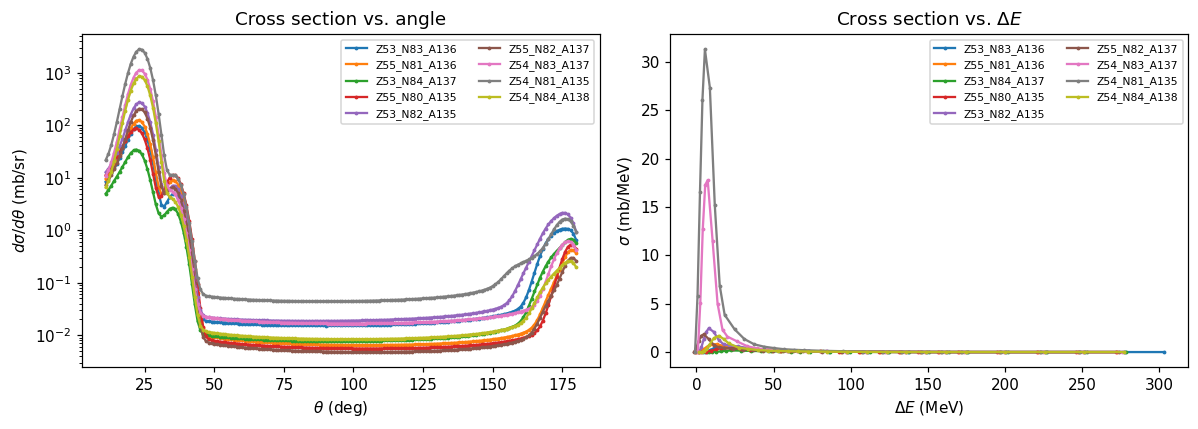

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for iso in isotopes:
    axes[0].plot(iso.angle_deg, iso.sigma_angle, marker=".", ms=3, label=iso.label)
    axes[1].plot(iso.energy_MeV, iso.sigma_energy, marker=".", ms=3, label=iso.label)

axes[0].set(xlabel=r"$\theta$ (deg)", ylabel=r"$d\sigma/d\theta$ (mb/sr)", yscale="log",
            title="Cross section vs. angle")
axes[1].set(xlabel=r"$\Delta E$ (MeV)", ylabel=r"$\sigma$ (mb/MeV)",
            title="Cross section vs. $\\Delta E$") # ylim = [min,max] to scale
axes[0].legend(fontsize=7, ncol=2)
axes[1].legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()


## 2. Event generation

Given the `sig_ang` / `sig_ene` cross-section files for one isotope, this Monte-Carlo samples `N`
(angle, ΔE) pairs weighted by the measured cross sections, giving a simulated event list for that
isotope.

### 2.1 Weighted sampling helper

Each cross-section table is treated as a piecewise-flat probability distribution: draw a random
number, find which data point's cumulative weight it falls under, then jitter the result
uniformly within a bin bounded by the midpoints to its neighbors. `sample_weighted` does this for
an entire array of draws at once (vectorized, no per-event Python loop).

In [17]:
def sample_weighted(values: np.ndarray, weights: np.ndarray, size: int, rng: np.random.Generator) -> np.ndarray:
    '''Draw `size` samples from a piecewise-flat PDF defined by (values, weights).

    Bin edges are the midpoints between consecutive `values`, extended symmetrically at the
    two ends.
    '''
    if len(values) == 1:
        # Only one data point for this isotope (very sparse GRAZING output for a weak
        # transfer channel) - no bin width to sample within, so every event takes that
        # single value. Worth flagging: results for this isotope are essentially a point
        # estimate, not a real distribution.
        return np.full(size, values[0])

    edges = np.empty(len(values) + 1)
    edges[1:-1] = (values[:-1] + values[1:]) / 2
    edges[0] = values[0] - (values[1] - values[0]) / 2
    edges[-1] = values[-1] + (values[-1] - values[-2]) / 2

    cumulative = np.cumsum(weights)
    total = cumulative[-1]

    draws = rng.uniform(0, total, size=size)
    idx = np.clip(np.searchsorted(cumulative, draws, side="left"), 0, len(values) - 1)

    lo, hi = edges[idx], edges[idx + 1]
    return lo + rng.uniform(0, 1, size=size) * (hi - lo)


### 2.2 Generating events for one isotope

Loads the cross-section files written out in §1.4 and samples `N` independent (angle, ΔE) events
from them.

In [18]:
def load_cross_section(path: str | Path) -> tuple[np.ndarray, np.ndarray]:
    # ndmin=2 keeps a single-row file as a 1x2 array (instead of collapsing to bare scalars),
    # so x/y always come out as proper arrays even for a very sparse/weak isotope channel.
    data = np.loadtxt(path, ndmin=2)
    return data[:, 0], data[:, 1]


def gen(
    run: str,
    Z: int,
    A: int,
    N: int = 100_000,
    dist_dir: str | Path = "distributions",
    seed: int | None = None,
) -> dict:
    dist_dir = Path(dist_dir)
    cross_A, cross_sigA = load_cross_section(dist_dir / f"sig_ang_{run}.dat")
    cross_E, cross_sigE = load_cross_section(dist_dir / f"sig_ene_{run}.dat")

    print(f"Read {len(cross_sigA)} sigma-vs-angle points, {len(cross_sigE)} sigma-vs-energy points")

    rng = np.random.default_rng(seed)
    delta_E = sample_weighted(cross_E, cross_sigE, N, rng)
    angle = sample_weighted(cross_A, cross_sigA, N, rng)

    return {
        "Z": Z, "A": A, "run": run,
        "angle": angle, "delta_E": delta_E,
        "cross_A": cross_A, "cross_sigA": cross_sigA,
        "cross_E": cross_E, "cross_sigE": cross_sigE,
    }


### 2.3 Running it

Using the 42Cl block parsed above (`Z=17, N=25`) and 100,000 generated events.

In [20]:
result = gen(
    run="z55_n83_run004",
    Z=55,
    A=138,
    N=100_000,
    dist_dir="distributions",
    seed=42,
)


Read 170 sigma-vs-angle points, 28 sigma-vs-energy points


### 2.4 Generated event distributions

Angle, ΔE, and their joint (angle vs. ΔE) distribution for the sampled events.

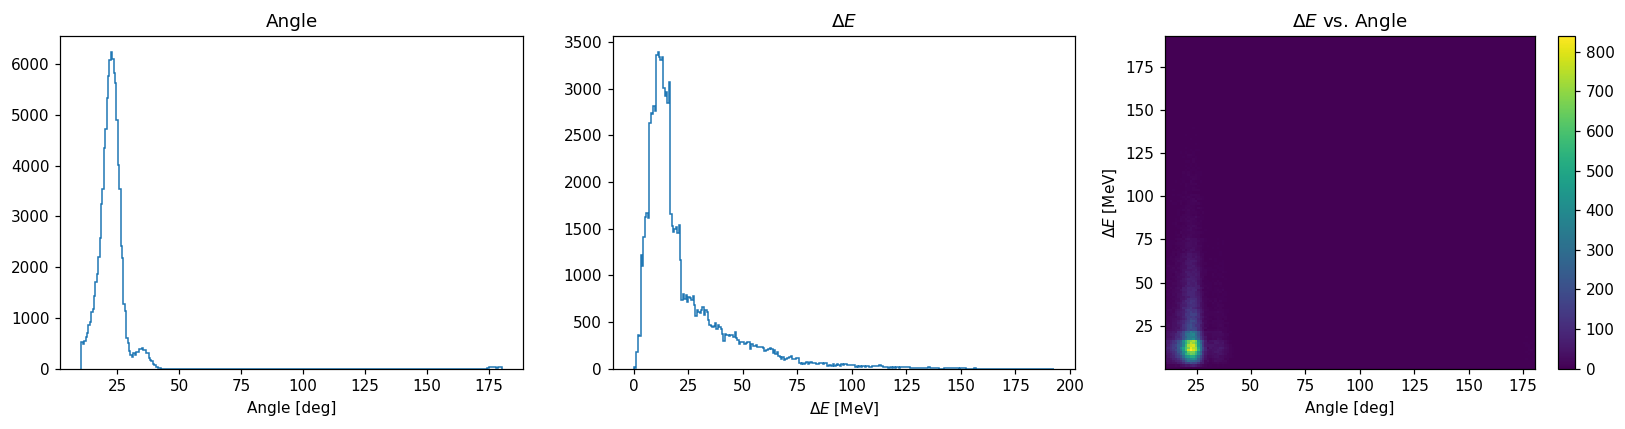

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(result["angle"], bins=300, histtype="step")
axes[0].set(xlabel="Angle [deg]", title="Angle")

axes[1].hist(result["delta_E"], bins=300, histtype="step")
axes[1].set(xlabel=r"$\Delta E$ [MeV]", title="$\\Delta E$")

h = axes[2].hist2d(result["angle"], result["delta_E"], bins=[150, 150], cmap="viridis")
axes[2].set(xlabel="Angle [deg]", ylabel=r"$\Delta E$ [MeV]", title="$\\Delta E$ vs. Angle")
fig.colorbar(h[3], ax=axes[2])

fig.tight_layout()
plt.show()


### 2.5 Handoff: event table

Packages the generated events into a plain table and writes it to CSV — this is what Part 5 below
reads in when a reaction's kinematics source is set to `"grazing"`.

In [22]:
events = pd.DataFrame({
    "angle_deg": result["angle"],
    "delta_E_MeV": result["delta_E"],
})
events["Z"] = result["Z"]
events["A"] = result["A"]
events["run"] = result["run"]

events_dir = Path("events")
events_dir.mkdir(exist_ok=True)
events_path = events_dir / f"events_z{result['Z']}_a{result['A']}_{result['run']}.csv"
events.to_csv(events_path, index=False)

print(f"Wrote {len(events)} events to {events_path}")
events.head()


Wrote 100000 events to events/events_z55_a138_z55_n83_run004.csv


,angle_deg,delta_E_MeV,Z,A,run
0,21.979330,34.008789,55,138,z55_n83_run004
1,20.911417,16.632391,55,138,z55_n83_run004
2,27.266644,44.230444,55,138,z55_n83_run004
3,23.240667,23.205535,55,138,z55_n83_run004
4,25.248812,6.574375,55,138,z55_n83_run004


### 2.6 Batch generation for many isotopes at once

For scanning across an isotopic chain (e.g. all Pt isotopes a run produces) instead of picking
one isotope by hand, `gen_batch` filters the isotopes found in Part 1 by `Z` and/or an `A` range,
then runs `gen()` for each one and writes out its events CSV automatically — same output format
as §2.5, one file per isotope, ready to hand to `build_grazing_reactions` in Part 4.

In [23]:
def gen_batch(
    isotopes: list[Isotope],
    run_label: str,
    Z_filter: int | None = None,
    A_range: tuple[int, int] | None = None,
    N: int = 100_000,
    dist_dir: str | Path = "distributions",
    events_dir: str | Path = "events",
    seed: int | None = None,
) -> dict[tuple[int, int], dict]:
    '''Run gen() for every isotope matching Z_filter / A_range, writing one events CSV each.

    `run_label` must match the run_label used in the parse_fort() call that produced these
    isotopes, since that's what the distribution filenames (sig_ang_*/sig_ene_*) are keyed on.

    Returns {(Z, A): {"result": gen()'s return dict, "events_path": Path}} for every isotope
    processed. Keyed on (Z, A) rather than A alone so isobars (e.g. 37P and 37S, both A=37)
    don't silently overwrite each other.
    '''
    selected = [
        iso for iso in isotopes
        if (Z_filter is None or iso.Z == Z_filter)
        and (A_range is None or A_range[0] <= iso.A <= A_range[1])
    ]
    if not selected:
        raise ValueError(
            f"No isotopes matched Z_filter={Z_filter}, A_range={A_range}. "
            f"Available: {[iso.label for iso in isotopes]}"
        )

    events_dir = Path(events_dir)
    events_dir.mkdir(exist_ok=True)
    rng = np.random.default_rng(seed)

    batch = {}
    for iso in selected:
        run = f"z{iso.Z}_n{iso.N}_{run_label}"
        result = gen(run=run, Z=iso.Z, A=iso.A, N=N, dist_dir=dist_dir,
                      seed=int(rng.integers(0, 2**32 - 1)))

        events = pd.DataFrame({"angle_deg": result["angle"], "delta_E_MeV": result["delta_E"]})
        events["Z"], events["A"], events["run"] = iso.Z, iso.A, run
        events_path = events_dir / f"events_z{iso.Z}_a{iso.A}_{run}.csv"
        events.to_csv(events_path, index=False)

        print(f"{iso.label}: wrote {len(events)} events to {events_path}")
        batch[(iso.Z, iso.A)] = {"result": result, "events_path": events_path}

    return batch


**Example (for once a Pt-target run is available):** parse that run the same way as §1.5, then
batch-generate all isotopes with `Z=78` (Pt) and mass number between 186 and 206:

```python
pt_isotopes, pt_header = parse_fort(DATA_DIR / "run_pt_target", run_label="run_pt_target", out_dir="distributions")
pt_batch = gen_batch(pt_isotopes, run_label="run_pt_target", Z_filter=78, A_range=(186, 206), N=100_000, seed=7)
```
`pt_batch` will then have one entry per isotope actually found in that range — check its length
against the expected 21 as a sanity check, the same way §1.5 warns about isotope-count mismatches.


## Notes

- **`angle_glitch_threshold`** (default 25°, Part 1) assumes real isotope-boundary resets are
  large (>25° drop) and glitch tails are small (~10-20° drop, as seen in `run100`). If a future
  run's isotopes are close together in angle, check the isotope-count warning in §1.5 and tune the
  threshold, or pass `angle_glitch_threshold=None` and clean the file by hand instead.
- **`kinematicsSource: "grazing"` only replaces the "Start of Target" distribution** in Part 5.
  "Middle" and "End" always use the `inelScatter` approximation, since GRAZING was only run at one
  (the full incident) beam energy — matching those would need separate GRAZING runs at the
  correspondingly degraded beam energies.
- **Processing many isotopes at once** (e.g. an isotopic chain like 21 Pt isotopes from a single
  run): use `gen_batch` (Part 2.6) to generate and write out events for every isotope matching a
  `Z`/`A` filter in one call, then `build_grazing_reactions` (Part 4.1) to turn that batch into
  `reactions` entries sharing one set of target/beam/degrader parameters. Parts 5-8 need no
  changes either way — they already loop over every entry in `reactions`.
- **`targetThickness`, `beamIonEnergy`, and the degrader/foil parameters are placeholders** for
  the bundled 42Cl reaction — replace them with your actual experimental values before trusting
  any of the downstream plots.
- For **249Cf targets** (missing entries in GRAZING's collective-state database),
  `parse_fort10_header` (Part 1) raises a clear `ValueError` if it can't find the `lab` marker at
  all, rather than silently mis-parsing — worth wrapping run batches in a try/except that logs
  which run directories failed.
- Parts 3-8 were written and reviewed but **not executed** while building this notebook (no SRIM
  install available in that environment) — run them end-to-end on your machine to confirm before
  relying on the numbers.
